<h1 style="color:rgb(199, 12, 77);">Final Prediction and Project Conclusion</h1>

The purpose of this notebook is to load the best-performing regression model, generate final predictions, interpret model performance, and summarize the overall findings of the Bitcoin price prediction project.

In [40]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import joblib
import os

In [41]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [42]:
df = pd.read_csv("../data/processed/bitcoin_model_ready.csv")

> <h3 style="color:rgb(247, 147, 26)">Loading the Best Model</h3>

> The best-performing model was loaded from the models directory using joblib.

> This allows the trained model to be reused without repeating the training process.

> Since the saved model includes the full pipeline, it can directly generate predictions using the prepared test data.

In [43]:
df.shape

(7535196, 22)

In [44]:
df.head()

,Open,High,Low,Close,Volume,Volatility,Year,Return,MA_60,MA_240,...,Month,Hour,DayOfWeek,Next_Close,Log_Return,Close_Lag_1,Close_Lag_5,Close_Lag_15,Return_Lag_1,Volume_Lag_1
0,5.0,5.0,5.0,5.0,0.0,0.0,2012,0.0,5.0,5.0,...,1,10,0,5.0,0.0,5.0,5.0,5.0,0.0,0.0
1,5.0,5.0,5.0,5.0,0.0,0.0,2012,0.0,5.0,5.0,...,1,10,0,5.0,0.0,5.0,5.0,5.0,0.0,0.0
2,5.0,5.0,5.0,5.0,0.0,0.0,2012,0.0,5.0,5.0,...,1,10,0,5.0,0.0,5.0,5.0,5.0,0.0,0.0
3,5.0,5.0,5.0,5.0,0.0,0.0,2012,0.0,5.0,5.0,...,1,10,0,5.0,0.0,5.0,5.0,5.0,0.0,0.0
4,5.0,5.0,5.0,5.0,0.0,0.0,2012,0.0,5.0,5.0,...,1,10,0,5.0,0.0,5.0,5.0,5.0,0.0,0.0


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7535196 entries, 0 to 7535195
Data columns (total 22 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Open                float64
 1   High                float64
 2   Low                 float64
 3   Close               float64
 4   Volume              float64
 5   Volatility          float64
 6   Year                int64  
 7   Return              float64
 8   MA_60               float64
 9   MA_240              float64
 10  MA_1440             float64
 11  Rolling_Volatility  float64
 12  Month               int64  
 13  Hour                int64  
 14  DayOfWeek           int64  
 15  Next_Close          float64
 16  Log_Return          float64
 17  Close_Lag_1         float64
 18  Close_Lag_5         float64
 19  Close_Lag_15        float64
 20  Return_Lag_1        float64
 21  Volume_Lag_1        float64
dtypes: float64(18), int64(4)
memory usage: 1.2 GB


In [46]:
best_model = joblib.load("../models/best_model_Lineer_Regression.pkl")

Linear Regression was selected as the final model because it achieved the lowest MAE and RMSE while maintaining the highest R2 score among the evaluated models.

In [47]:
X = df.drop("Next_Close",axis=1)
y = df["Next_Close"]

The same feature structure used during training is preserved to ensure that the saved model receives the correct input format.

In [48]:
split = int(len(df) *0.8)

train = df.iloc[:split]

test = df.iloc[split:]

In [49]:
X_train = train.drop("Next_Close",axis=1)

X_test = test.drop("Next_Close",axis=1)

y_train = train["Next_Close"]

y_test = test["Next_Close"]

> <h3 style="color:rgb(247, 147, 26)">Feature and Target Preparation</h3>

> The target variable is Next_Close, which represents the next 1-minute Bitcoin closing price.

> All remaining columns are used as input features for the final prediction process.

> Keeping the same feature structure as the training notebook is important because the saved model expects the same input format.

In [50]:
y_pred_final = best_model.predict(X_test)

> <h3 style="color:rgb(247, 147, 26)">Final Prediction</h3>

> The loaded model was used to generate final predictions on the test dataset.

> These predictions represent the model's estimated next 1-minute Bitcoin closing prices.

> This step demonstrates that the saved model can be reused for prediction without being trained again.

In [51]:
mae = mean_absolute_error(y_test,y_pred_final)
mse = mean_squared_error(y_test,y_pred_final)
r2 = r2_score(y_test,y_pred_final)
rmse = np.sqrt(mse)

In [52]:
scores = pd.DataFrame({
    "Model":"Linear Regression",
    "MAE":[mae],
    "R2 Score":[r2],
    "RMSE":[rmse]
})

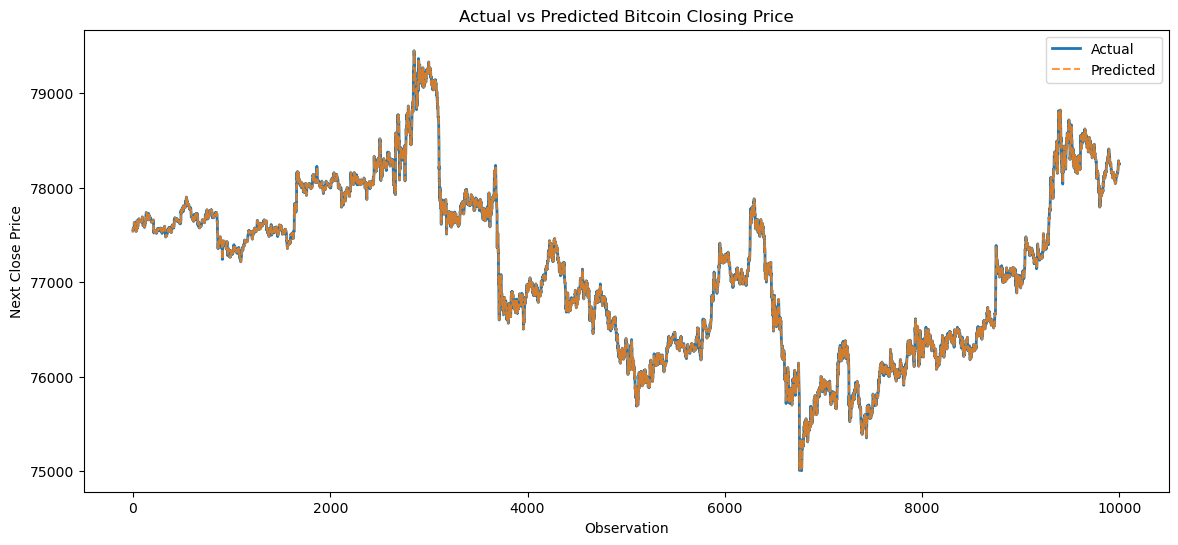

In [77]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_final
})

sample_df = comparison_df.tail(10_000)

plt.figure(figsize=(14,6))

plt.plot(
    sample_df["Actual"].values, 
    label="Actual", 
    linewidth=2)

plt.plot(
    sample_df["Predicted"].values, 
    label="Predicted", 
    linestyle="--", alpha=0.8)

plt.title("Actual vs Predicted Bitcoin Closing Price")
plt.xlabel("Observation")
plt.ylabel("Next Close Price")
plt.legend()
plt.savefig("../outputs/figures/notebook5_figures/Actual_vs_Predicted")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Actual vs Predicted Prices</h3>

> This chart compares the actual Bitcoin next closing prices with the model's predicted values.

> The predicted values closely follow the actual values, which indicates that the model captures short-term price movements effectively.

> From a market perspective, this suggests that recent price behavior, lag features, moving averages, returns, and volatility-based features provide useful information for next-minute price prediction.

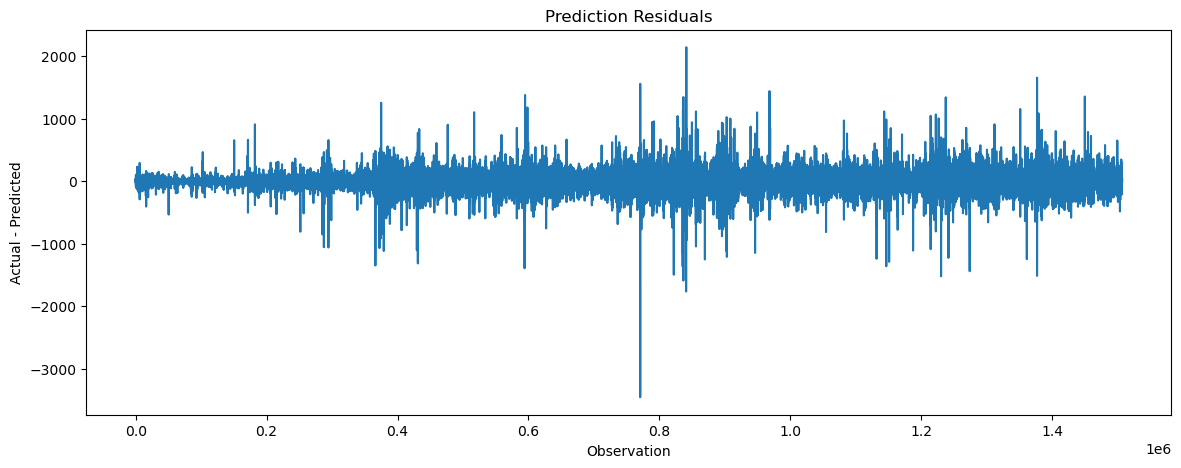

In [76]:
comparison_df["Residual"] = (
    comparison_df["Actual"] - comparison_df["Predicted"]
)

plt.figure(figsize=(14,5))
plt.plot(comparison_df["Residual"].values)

plt.title("Prediction Residuals")
plt.xlabel("Observation")
plt.ylabel("Actual - Predicted")
plt.savefig("../outputs/figures/notebook5_figures/Prediction Residuals")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Prediction Residuals</h3>

> Residuals represent the difference between actual and predicted values.

> Smaller residual values indicate that the model's predictions are close to the real Bitcoin prices.

> Larger residual spikes may occur during sudden market movements, which are harder for the model to predict accurately.

In [88]:
comparison_df["Error"] = comparison_df["Actual"] - comparison_df["Predicted"]
comparison_df["Absolute_Error"] = abs(comparison_df["Error"])
comparison_df["Percentage_Error"] = (
    comparison_df["Absolute_Error"] / comparison_df["Actual"]
) * 100

In [89]:
mean_percentage_error = Percentage_Error.mean()
mean_percentage_error

np.float64(0.025973738826549613)

In [90]:
max_error = Percentage_Error.max()
max_error

np.float64(0.1496783159488468)

In [91]:
min_error = Percentage_Error.min()
min_error

np.float64(0.00010595244979035584)

In [92]:
error_summary = pd.DataFrame({
    "Metric": ["Mean % Error", "Max % Error", "Min % Error"],
    "Value": [mean_percentage_error, max_error, min_error]
})

error_summary

,Metric,Value
0,Mean % Error,0.025974
1,Max % Error,0.149678
2,Min % Error,0.000106


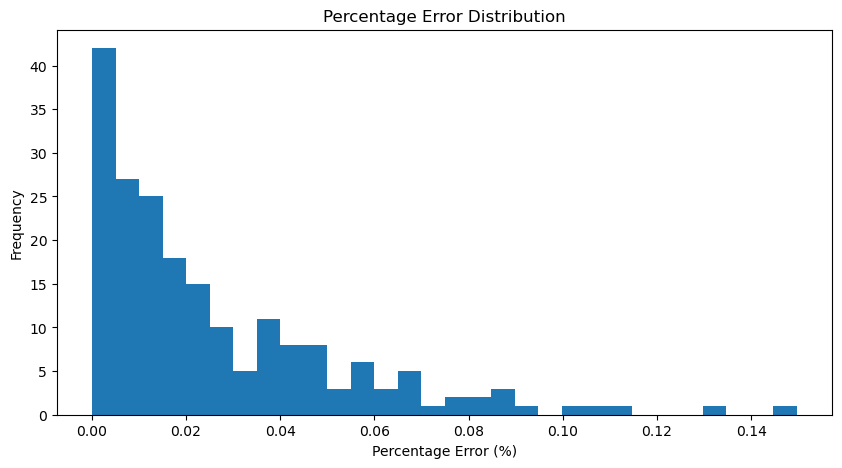

In [75]:
plt.figure(figsize=(10,5))
plt.hist(Percentage_Error, bins=30)

plt.title("Percentage Error Distribution")
plt.xlabel("Percentage Error (%)")
plt.ylabel("Frequency")
plt.savefig("../outputs/figures/notebook5_figures/Percentage Error Distribution")

plt.show()

> <h3 style="color:rgb(247, 147, 26)">Prediction Error Analysis</h3>

> Percentage error measures the relative difference between actual and predicted Bitcoin closing prices.

> The average percentage error provides an interpretable view of prediction accuracy in percentage terms.

> This is important because price-level errors can be harder to interpret when Bitcoin prices vary significantly over time.

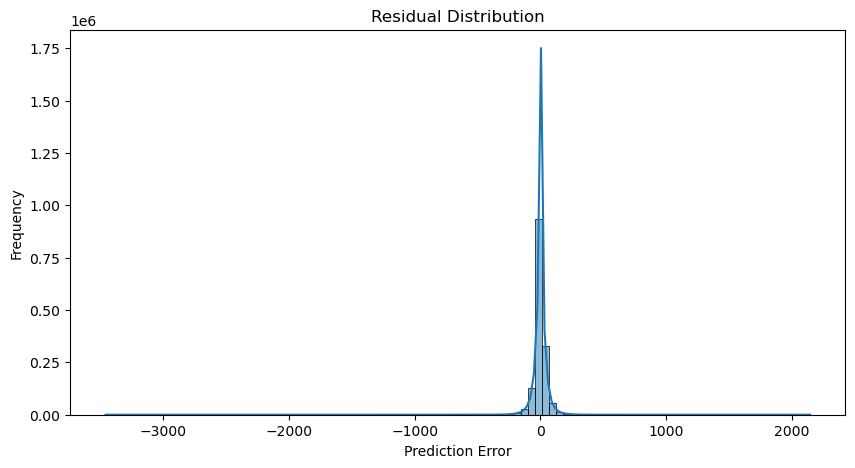

In [74]:
comparison_df["Residual"] = comparison_df["Actual"] - comparison_df["Predicted"]

plt.figure(figsize=(10,5))
sns.histplot(comparison_df["Residual"], bins=100, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.savefig("../outputs/figures/notebook5_figures/Residual Distribution")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Prediction Error Analysis</h3>

> Percentage error measures the relative difference between actual and predicted Bitcoin closing prices.

> The average percentage error provides an interpretable view of prediction accuracy in percentage terms.

> This is important because price-level errors can be harder to interpret when Bitcoin prices vary significantly over time.

In [83]:
comparison_df["Error"] = comparison_df["Actual"] - comparison_df["Predicted"]

comparison_df["Absolute_Error"] = abs(comparison_df["Error"])

comparison_df["Percentage_Error"] = (
    comparison_df["Absolute_Error"] / comparison_df["Actual"]
) * 100

In [84]:
sample_predictions = comparison_df.tail(10).copy()

sample_predictions[[
    "Actual",
    "Predicted",
    "Error",
    "Absolute_Error",
    "Percentage_Error"
]]

,Actual,Predicted,Error,Absolute_Error,Percentage_Error
1507030,78244.0,78249.451678,-5.451678,5.451678,0.006968
1507031,78285.0,78242.990688,42.009312,42.009312,0.053662
1507032,78275.0,78283.937514,-8.937514,8.937514,0.011418
1507033,78258.0,78273.772739,-15.772739,15.772739,0.020155
1507034,78250.0,78256.942162,-6.942162,6.942162,0.008872
1507035,78251.0,78248.905639,2.094361,2.094361,0.002676
1507036,78245.0,78249.671602,-4.671602,4.671602,0.005970
1507037,78254.0,78243.937374,10.062626,10.062626,0.012859
1507038,78256.0,78252.424924,3.575076,3.575076,0.004568
1507039,78251.0,78254.338549,-3.338549,3.338549,0.004266


> <h3 style="color:rgb(247, 147, 26)">Sample Prediction Results</h3>

> This table shows a small sample of actual and predicted Bitcoin closing prices.

> It makes the model's prediction behavior easier to interpret compared to summary metrics alone.

> The results show how close the model predictions are to real next-minute Bitcoin prices in individual examples.

<h2 style="color:rgb(199, 12, 77)">Interpretation of Final Results</h2>

The final model achieved strong performance in predicting the next 1-minute Bitcoin closing price.

This result should be interpreted carefully because the target is a very short-term price value. In high-frequency data, consecutive prices are usually close to each other.

Therefore, the model is effective for short-horizon prediction, but it should not be interpreted as a long-term Bitcoin forecasting system.

<h2 style="color:rgb(199, 12, 77)">Model Limitations</h2>

This model uses only historical OHLCV data and engineered features derived from price, volume, volatility, and time.

It does not include external factors such as news sentiment, macroeconomic indicators, regulations, investor behavior, or major market events.

As a result, the model may perform well during normal short-term market conditions but may struggle during sudden crashes, pump movements, or unexpected volatility events.

<h3 style="color:rgb(47, 247, 126)">Future Improvements</h3>

Future versions of this project could test longer prediction horizons such as 5-minute, 1-hour, or 1-day ahead predictions.

The project could also be extended by predicting returns or price direction instead of directly predicting the next closing price.

More advanced models such as XGBoost, LightGBM, LSTM, or GRU could be tested, and external data such as news sentiment, macroeconomic indicators, or crypto market indexes could be added.

In [85]:
scores.to_csv("../outputs/reports/final_model_metrics.csv", index=False)
error_summary.to_csv("../outputs/reports/final_error_summary.csv", index=False)
comparison_df.tail(1000).to_csv("../outputs/reports/final_prediction_results.csv", index=False)

<h1 style="color:rgb(199, 12, 77)">Final Project Conclusion</h1>

This project demonstrated a complete machine learning workflow for short-term Bitcoin price prediction.

The dataset was loaded, explored, cleaned, transformed with engineered features, and used to train multiple regression models.

The final selected model was loaded from disk and used to generate predictions without retraining.

The results show that lag features, moving averages, returns, and volatility indicators can provide useful predictive information for next-minute Bitcoin price prediction.

However, the model should be understood as a short-horizon forecasting model rather than a long-term investment prediction tool.

Overall, the project successfully applies exploratory data analysis, feature engineering, regression modeling, model evaluation, and final prediction interpretation in a structured machine learning workflow.